# CSCI 164 Project: Comparing Supervised Learning Models Across Multiple Datasets with scikit-learn  
Marquez Barba

## Intro
The goal of this project is to compare how different supervised learning models perform across several datasets using scikit-learn. I used two classification datasets and one regression dataset so my project would include both major types of supervised learning tasks. For each dataset, I explored the data, prepared it for modeling, trained multiple baseline models, tuned important hyperparameters, and evaluated the results with metrics and visualizations that fit the problem.

A second goal of this project is to show that model performance depends on the structure of the dataset. Some problems are easier because the classes are more clearly separated, while others need more tuning or more preprocessing before strong results appear. By using multiple datasets instead of only one, my notebook shows that there is no single model that automatically works best in every situation.

The three datasets used in this project are:
- Wisconsin Diagnostic Breast Cancer for binary classification  
- Dry Bean for multiclass classification  
- Diamonds for regression  

This makes my project more balanced with different data structures, different modeling challenges, and different evaluation methods.

In [104]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

## Helper functions
To keep my notebook organized, I created a few helper functions for evaluating classification and regression models. This makes it easier to compare results across different datasets without repeating my code.

In [105]:
def evaluate_binary_classification(y_true, y_pred, y_prob, model_name):
    return pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Precision": [precision_score(y_true, y_pred)],
        "Recall": [recall_score(y_true, y_pred)],
        "F1": [f1_score(y_true, y_pred)],
        "ROC-AUC": [roc_auc_score(y_true, y_prob)],
    })
def evaluate_multiclass(y_true, y_pred, model_name):
    return pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Precision": [precision_score(y_true, y_pred, average="weighted")],
        "Recall": [recall_score(y_true, y_pred, average="weighted")],
        "F1": [f1_score(y_true, y_pred, average="weighted")],
    })
def evaluate_regression(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    return pd.DataFrame({
        "Model": [model_name],
        "MAE": [mean_absolute_error(y_true, y_pred)],
        "MSE": [mse],
        "RMSE": [np.sqrt(mse)],
        "R2": [r2_score(y_true, y_pred)],
    })
def print_cv_scores(model, X, y, scoring, label):
    scores = cross_val_score(model, X, y, cv=5, scoring=scoring)
    print(label)
    print(f"CV {scoring} scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())
    print()

# Dataset 1: Wisconsin Diagnostic Breast Cancer
## Why I chose this dataset
I chose the Wisconsin Diagnostic Breast Cancer dataset because it is a binary classification problem with numerical features, which makes it a strong dataset for comparing different supervised learning models. It also works well for showing how preprocessing, especially scaling, affects models such as Logistic Regression and K-Nearest Neighbors. Since the target is whether a tumor is benign or malignant, it also gives a good example of a classification problem where precision, recall, F1-score, ROC-AUC, and confusion matrices all matter.

In [106]:
cancer = pd.read_csv("../data/WisconsinBreastCancerDatabase.csv")

print("First five rows:")
display(cancer.head())

print("\nDataset info:")
cancer.info()

First five rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se          

In [107]:
print("\nMissing values:")
print(cancer.isnull().sum())

print("\nSummary statistics:")
display(cancer.describe())


Missing values:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_wors

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


## Dataset overview
This dataset contains measurements computed from breast cell images. The target variable is diagnosis, where each case is labeled as either benign (B) or malignant (M). Most of the predictor variables are continuous numerical measurements such as radius, texture, perimeter, area, smoothness, and concavity. Since the dataset is mostly numerical, preprocessing is fairly direct.
When I inspected the data, I found one extra empty column named Unnamed: 32, which needed to be removed before training the models.

In [108]:
if "Unnamed: 32" in cancer.columns:
    cancer = cancer.drop(columns=["Unnamed: 32"])
X_cancer = cancer.drop(columns=["id", "diagnosis"])
y_cancer = cancer["diagnosis"].map({"B": 0, "M": 1})
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cancer,
    y_cancer,
    test_size=0.2,
    random_state=42,
    stratify=y_cancer
)
scaler_cancer = StandardScaler()
Xc_train_scaled = scaler_cancer.fit_transform(Xc_train)
Xc_test_scaled = scaler_cancer.transform(Xc_test)

The preprocessing for this dataset was simple but important. I removed the empty Unnamed: 32 column because it did not contain useful information. I also removed the id column because it's only an identifier and doesn't help with prediction. The diagnosis labels were converted from B and M into 0 and 1 so the classifiers could use them directly.
After that, I split the data into training and testing sets using stratification so the class balance would stay similar in both sets. Finally, I standardized the predictor variables for Logistic Regression and KNN, since those models are affected by feature scale.

## Model choice
For this dataset, I used three classification models:
- Logistic Regression as a simple and interpretable baseline
- K-Nearest Neighbors (KNN) because it often performs well on scaled numerical data
- Decision Tree because it can model nonlinear decision boundaries and does not require scaling

This gave a useful comparison between a linear model, a distance-based model, and a tree-based model.

In [109]:
log_cancer = LogisticRegression(max_iter=1000, random_state=42)
knn_cancer = KNeighborsClassifier()
tree_cancer = DecisionTreeClassifier(random_state=42)

log_cancer.fit(Xc_train_scaled, yc_train)
knn_cancer.fit(Xc_train_scaled, yc_train)
tree_cancer.fit(Xc_train, yc_train)

yc_pred_log = log_cancer.predict(Xc_test_scaled)
yc_prob_log = log_cancer.predict_proba(Xc_test_scaled)[:, 1]

yc_pred_knn = knn_cancer.predict(Xc_test_scaled)
yc_prob_knn = knn_cancer.predict_proba(Xc_test_scaled)[:, 1]

yc_pred_tree = tree_cancer.predict(Xc_test)
yc_prob_tree = tree_cancer.predict_proba(Xc_test)[:, 1]

In [110]:
cancer_results = pd.concat([
    evaluate_binary_classification(yc_test, yc_pred_log, yc_prob_log, "Logistic Regression"),
    evaluate_binary_classification(yc_test, yc_pred_knn, yc_prob_knn, "KNN"),
    evaluate_binary_classification(yc_test, yc_pred_tree, yc_prob_tree, "Decision Tree"),
], ignore_index=True)
cancer_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
1,KNN,0.956140,0.974359,0.904762,0.938272,0.982308
2,Decision Tree,0.929825,0.904762,0.904762,0.904762,0.924603


## Baseline results
All three baseline models performed well on this dataset, but Logistic Regression produced the strongest overall results. KNN was close behind, while Decision Tree was the weakest of the three. This suggests that the classes in this dataset are already separated well enough that a simpler linear model can perform extremely well.

In [111]:
print("Classification report (Logistic Regression)")
print(classification_report(yc_test, yc_pred_log))

print("\nClassification report (KNN)")
print(classification_report(yc_test, yc_pred_knn))

Classification report (Logistic Regression)
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Classification report (KNN)
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [112]:
print("\nClassification report (Decision Tree)")
print(classification_report(yc_test, yc_pred_tree))


Classification report (Decision Tree)
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



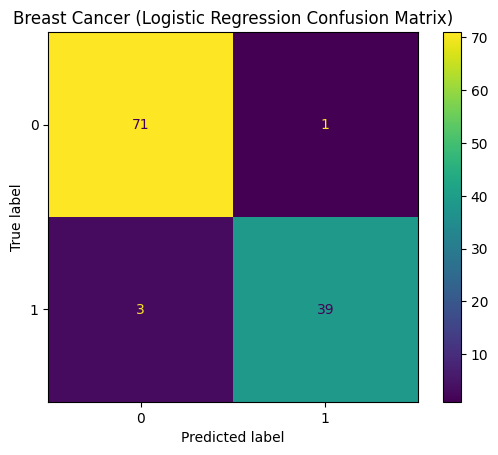

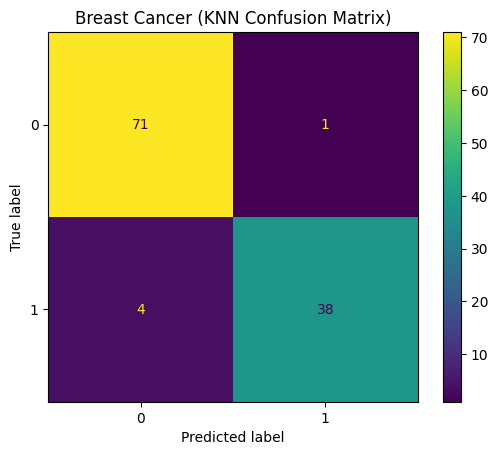

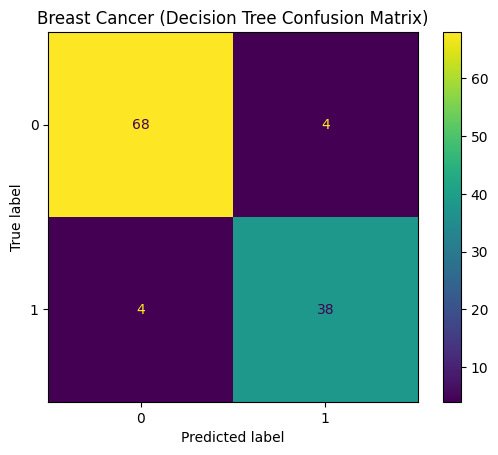

In [113]:
ConfusionMatrixDisplay.from_predictions(yc_test, yc_pred_log)
plt.title("Breast Cancer (Logistic Regression Confusion Matrix)")
plt.savefig("../figures/breast_cancer_logistic_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

ConfusionMatrixDisplay.from_predictions(yc_test, yc_pred_knn)
plt.title("Breast Cancer (KNN Confusion Matrix)")
plt.show()

ConfusionMatrixDisplay.from_predictions(yc_test, yc_pred_tree)
plt.title("Breast Cancer (Decision Tree Confusion Matrix)")
plt.show()

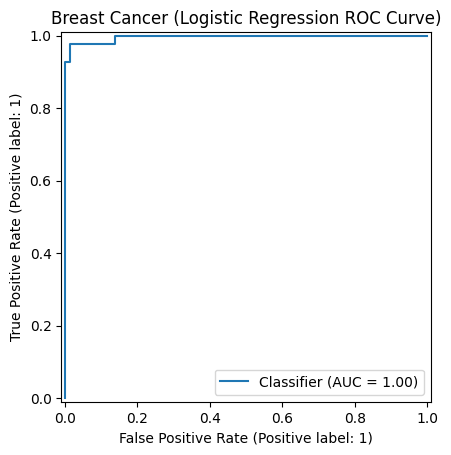

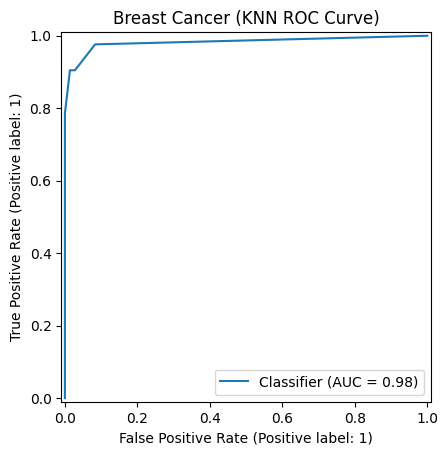

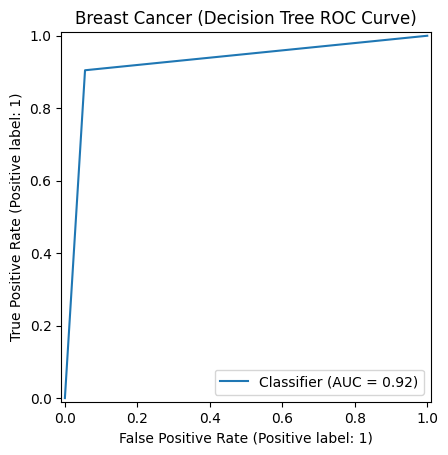

In [114]:
RocCurveDisplay.from_predictions(yc_test, yc_prob_log)
plt.title("Breast Cancer (Logistic Regression ROC Curve)")
plt.savefig("../figures/breast_cancer_logistic_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

RocCurveDisplay.from_predictions(yc_test, yc_prob_knn)
plt.title("Breast Cancer (KNN ROC Curve)")
plt.show()

RocCurveDisplay.from_predictions(yc_test, yc_prob_tree)
plt.title("Breast Cancer (Decision Tree ROC Curve)")
plt.show()

The classification reports, confusion matrices, and ROC curves all support the same conclusion. Logistic Regression gave the cleanest overall performance and the highest ROC-AUC. KNN also performed strongly, but it made slightly more errors than Logistic Regression. Decision Tree was still usable, but it showed lower accuracy and weaker overall separation between the two classes.
This is important because accuracy alone does not tell the full story. Since this dataset is based on cancer diagnosis, recall is especially important because false negatives are more serious than many other classification mistakes.

In [115]:
print_cv_scores(
    LogisticRegression(max_iter=1000, random_state=42),
    scaler_cancer.fit_transform(X_cancer),
    y_cancer,
    "accuracy",
    "Breast Cancer Logistic Regression"
)

print_cv_scores(
    KNeighborsClassifier(),
    scaler_cancer.fit_transform(X_cancer),
    y_cancer,
    "accuracy",
    "Breast Cancer KNN"
)

print_cv_scores(
    DecisionTreeClassifier(random_state=42),
    X_cancer,
    y_cancer,
    "accuracy",
    "Breast Cancer Decision Tree"
)

Breast Cancer Logistic Regression
CV accuracy scores: [0.98245614 0.98245614 0.97368421 0.97368421 0.99115044]
Mean: 0.9806862288464524
Standard deviation: 0.006539441283506109

Breast Cancer KNN
CV accuracy scores: [0.96491228 0.95614035 0.98245614 0.95614035 0.96460177]
Mean: 0.9648501785437045
Standard deviation: 0.009609970350036127

Breast Cancer Decision Tree
CV accuracy scores: [0.9122807  0.90350877 0.92982456 0.95614035 0.88495575]
Mean: 0.9173420276354604
Standard deviation: 0.02419491828674519



The cross-validation results were consistent with the test-set results. Logistic Regression had the highest average cross-validation accuracy, followed by KNN, while Decision Tree showed the most variation across folds. That supports the earlier conclusion that Logistic Regression was the most stable model for this dataset.

## Hyperparameter tuning
To see whether the models could be improved, I used GridSearchCV on KNN and Decision Tree. These two models are sensitive to their parameter settings. For KNN, the number of neighbors and the weighting method can affect how flexible the decision boundary becomes. For Decision Tree, depth and split settings can strongly affect overfitting and generalization.

In [116]:
knn_cancer_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 13],
    "weights": ["uniform", "distance"]
}

knn_cancer_search = GridSearchCV(
    KNeighborsClassifier(),
    knn_cancer_grid,
    cv=5,
    scoring="f1"
)
knn_cancer_search.fit(Xc_train_scaled, yc_train)

print("Best KNN params:", knn_cancer_search.best_params_)
print("Best KNN CV F1:", knn_cancer_search.best_score_)

Best KNN params: {'n_neighbors': 3, 'weights': 'uniform'}
Best KNN CV F1: 0.9570803988714436


In [117]:
tree_cancer_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

tree_cancer_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    tree_cancer_grid,
    cv=5,
    scoring="f1"
)
tree_cancer_search.fit(Xc_train, yc_train)

print("Best Tree params:", tree_cancer_search.best_params_)
print("Best Tree CV F1:", tree_cancer_search.best_score_)

Best Tree params: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Tree CV F1: 0.9227170893134552


In [118]:
best_knn_cancer = knn_cancer_search.best_estimator_
best_tree_cancer = tree_cancer_search.best_estimator_

best_knn_cancer.fit(Xc_train_scaled, yc_train)
best_tree_cancer.fit(Xc_train, yc_train)

yc_pred_knn_tuned = best_knn_cancer.predict(Xc_test_scaled)
yc_prob_knn_tuned = best_knn_cancer.predict_proba(Xc_test_scaled)[:, 1]

yc_pred_tree_tuned = best_tree_cancer.predict(Xc_test)
yc_prob_tree_tuned = best_tree_cancer.predict_proba(Xc_test)[:, 1]

cancer_tuned_results = pd.concat([
    evaluate_binary_classification(yc_test, yc_pred_log, yc_prob_log, "Logistic Regression"),
    evaluate_binary_classification(yc_test, yc_pred_knn_tuned, yc_prob_knn_tuned, "Tuned KNN"),
    evaluate_binary_classification(yc_test, yc_pred_tree_tuned, yc_prob_tree_tuned, "Tuned Decision Tree"),
], ignore_index=True)

cancer_tuned_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
1,Tuned KNN,0.938596,0.972973,0.857143,0.911392,0.982474
2,Tuned Decision Tree,0.938596,0.948718,0.880952,0.913580,0.922454


## Breast cancer analysis
The breast cancer dataset was one of the strongest-performing datasets in the project. All three baseline models produced good results, but Logistic Regression performed the best overall. It had the highest ROC-AUC and the strongest overall balance of accuracy, precision, recall, and F1-score. KNN also performed well, but it was slightly behind Logistic Regression. Decision Tree was the weakest of the three baseline models and made more classification errors.
The cross-validation results supported the same overall pattern. Logistic Regression had the highest average cross-validation accuracy, followed by KNN, while Decision Tree showed the most variation across folds. This suggests that Logistic Regression was not only the most accurate model on the test set, but also the most stable one across different splits of the data.
The tuning results were also important because they did not improve on the Logistic Regression baseline. In this case, the simplest model ended up being the best one. That suggests the dataset is already structured in a way that a linear classifier can handle very effectively. The confusion matrices and ROC curves support that conclusion, since Logistic Regression gave the cleanest separation between the two classes.

# Dataset 2: Dry Bean
## Why I chose this dataset
I chose the Dry Bean dataset because it's a multiclass classification problem, which adds variety to my project. It also contains shape based numerical features, which makes it useful for comparing models on structured data. This dataset is a good contrast to the breast cancer dataset because the task is harder and involves more than two possible classes.

In [119]:
beans = pd.read_csv("../data/Dry_Bean_Data.csv")

print("First five rows:")
display(beans.head())

print("\nDataset info:")
beans.info()

First five rows:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER



Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float

In [120]:
print("Missing values:")
print(beans.isnull().sum())

print("\nClass counts:")
print(beans["Class"].value_counts())

print("\nSummary statistics:")
display(beans.describe())

Missing values:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Class counts:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Summary statistics:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


## Dataset overview
The target variable in this dataset is Class, which represents the bean variety. Unlike the breast cancer dataset, this is a multiclass problem, so the evaluation needs to focus on weighted precision, weighted recall, weighted F1-score, and confusion matrices that show which classes are getting mixed up.
Since the predictors are numerical, preprocessing mainly involves scaling the features for models that depend on distance or optimization.

In [121]:
X_beans = beans.drop(columns=["Class"])
y_beans = beans["Class"]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_beans,
    y_beans,
    test_size=0.2,
    random_state=42,
    stratify=y_beans
)

scaler_beans = StandardScaler()
Xb_train_scaled = scaler_beans.fit_transform(Xb_train)
Xb_test_scaled = scaler_beans.transform(Xb_test)

The preprocessing for this dataset was straightforward. I separated the predictors from the target column, then split the data into training and testing sets using stratification so the class balance would stay similar in both sets. Because the features are numerical and some of the models depend on distance or optimization, I standardized the predictors before training.

## Model choice
For this dataset, I used three classifiers:
- Logistic Regression as a multiclass baseline
- KNN because distance-based models can work well on scaled geometric features
- MLPClassifier because the class boundaries may be more complicated than what a simple linear model can capture

This gives a useful comparison between a linear classifier, a neighborhood-based model, and a neural-network-based classifier.

In [122]:
log_beans = LogisticRegression(max_iter=2000, random_state=42)
knn_beans = KNeighborsClassifier()
mlp_beans = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)

log_beans.fit(Xb_train_scaled, yb_train)
knn_beans.fit(Xb_train_scaled, yb_train)
mlp_beans.fit(Xb_train_scaled, yb_train)

yb_pred_log = log_beans.predict(Xb_test_scaled)
yb_pred_knn = knn_beans.predict(Xb_test_scaled)
yb_pred_mlp = mlp_beans.predict(Xb_test_scaled)

In [123]:
bean_results = pd.concat([
    evaluate_multiclass(yb_test, yb_pred_log, "Logistic Regression"),
    evaluate_multiclass(yb_test, yb_pred_knn, "KNN"),
    evaluate_multiclass(yb_test, yb_pred_mlp, "MLPClassifier"),
], ignore_index=True)

bean_results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.920676,0.921533,0.920676,0.920873
1,KNN,0.916636,0.917409,0.916636,0.916805
2,MLPClassifier,0.928021,0.928036,0.928021,0.927752


## Baseline results
All three baseline models performed well on this dataset, but MLPClassifier produced the best overall results. Logistic Regression was close behind and gave strong multiclass performance, while KNN was slightly lower than the other two. This suggests that the Dry Bean classes are not perfectly separated and that a more flexible model handles the structure of the data a little better.

In [124]:
print("Classification report (Logistic Regression)")
print(classification_report(yb_test, yb_pred_log))

print("\nClassification report (KNN)")
print(classification_report(yb_test, yb_pred_knn))

Classification report (Logistic Regression)
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.93      0.95      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723


Classification report (KNN)
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.88      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.91      0.91      0.91       709
       HOROZ       0.95      0.95      0.95       386
     

In [125]:
print("\nClassification report (MLPClassifier)")
print(classification_report(yb_test, yb_pred_mlp))


Classification report (MLPClassifier)
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.90      0.94      0.92       709
       HOROZ       0.97      0.96      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.90      0.85      0.87       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



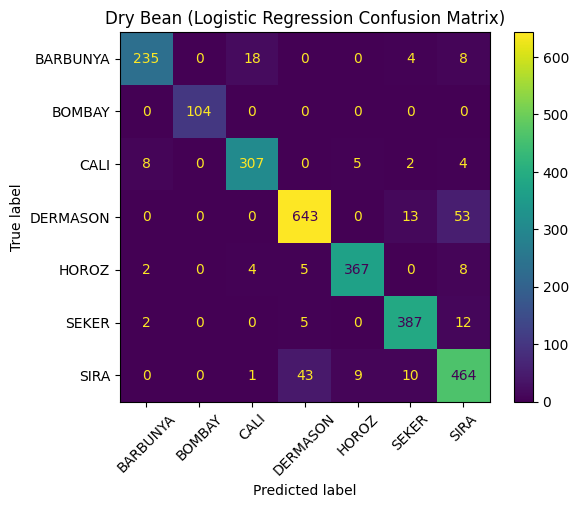

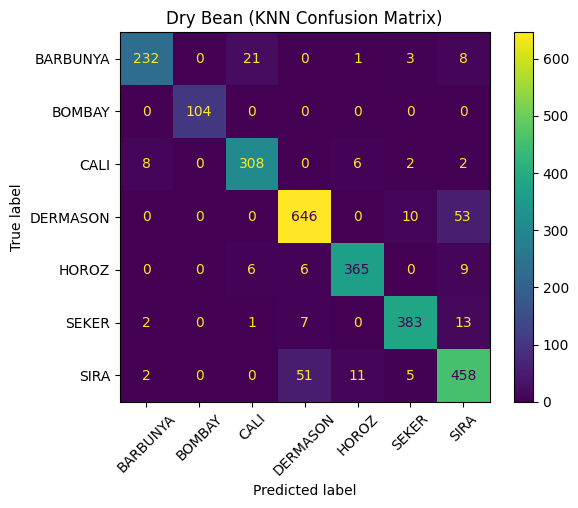

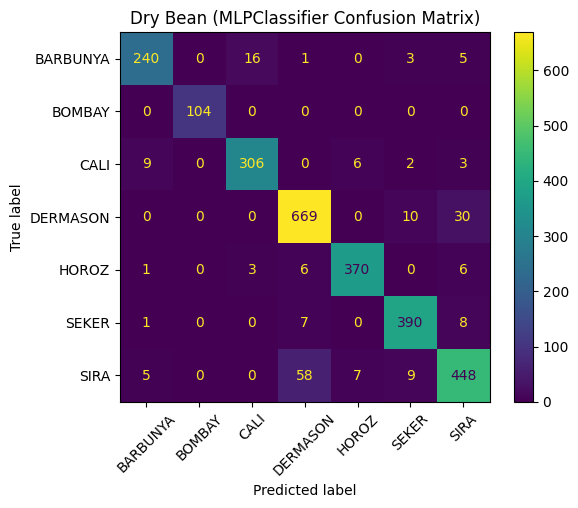

In [126]:
ConfusionMatrixDisplay.from_predictions(yb_test, yb_pred_log, xticks_rotation=45)
plt.title("Dry Bean (Logistic Regression Confusion Matrix)")
plt.savefig("../figures/dry_bean_logistic_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

ConfusionMatrixDisplay.from_predictions(yb_test, yb_pred_knn, xticks_rotation=45)
plt.title("Dry Bean (KNN Confusion Matrix)")
plt.show()

ConfusionMatrixDisplay.from_predictions(yb_test, yb_pred_mlp, xticks_rotation=45)
plt.title("Dry Bean (MLPClassifier Confusion Matrix)")
plt.savefig("../figures/dry_bean_mlp_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

The confusion matrices show that some bean varieties are easier to classify than others. A few classes are predicted very accurately, while others get confused with visually similar groups. That makes sense for a multiclass problem like this, where some class boundaries are naturally more difficult than others. The classification reports support the same pattern, with MLPClassifier giving the strongest overall weighted performance.

## Cross-validation
To get a second view of model stability, I also used cross-validation. For this part, I used pipelines so that scaling happened inside each fold instead of being applied to the full dataset ahead of time. That gives a more reliable estimate of how the models perform across different train/test splits.

In [127]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_beans_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

knn_beans_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

mlp_beans_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42))
])

log_cv_scores = cross_val_score(log_beans_pipe, X_beans, y_beans, cv=cv, scoring="accuracy")
knn_cv_scores = cross_val_score(knn_beans_pipe, X_beans, y_beans, cv=cv, scoring="accuracy")
mlp_cv_scores = cross_val_score(mlp_beans_pipe, X_beans, y_beans, cv=cv, scoring="accuracy")

print("Dry Bean Logistic Regression")
print("CV accuracy scores:", log_cv_scores)
print("Mean:", log_cv_scores.mean())
print("Standard deviation:", log_cv_scores.std())
print()

print("Dry Bean KNN")
print("CV accuracy scores:", knn_cv_scores)
print("Mean:", knn_cv_scores.mean())
print("Standard deviation:", knn_cv_scores.std())
print()

print("Dry Bean MLPClassifier")
print("CV accuracy scores:", mlp_cv_scores)
print("Mean:", mlp_cv_scores.mean())
print("Standard deviation:", mlp_cv_scores.std())

Dry Bean Logistic Regression
CV accuracy scores: [0.91369813 0.92983101 0.92211609 0.92872888 0.92578986]
Mean: 0.9240327922022729
Standard deviation: 0.0058178832398131

Dry Bean KNN
CV accuracy scores: [0.91700331 0.92983101 0.92468773 0.92725937 0.92064658]
Mean: 0.9238855985815446
Standard deviation: 0.004587609258875259

Dry Bean MLPClassifier
CV accuracy scores: [0.92104297 0.93387215 0.93166789 0.93681117 0.93497428]
Mean: 0.9316736926548629
Standard deviation: 0.005570155084013879


The cross-validation results were consistent with the test set results. MLPClassifier had the highest average cross-validation accuracy at about 0.932, while Logistic Regression and KNN were both close to 0.924. The standard deviations were small, which suggests that the models performed fairly consistently across different folds of the dataset.

## Hyperparameter tuning
To see whether the models could be improved, I tuned KNN and MLPClassifier. On multiclass problems, parameter changes can affect how well the model separates overlapping classes. KNN depends heavily on neighborhood size, while MLP depends on hidden-layer structure and regularization strength.

In [128]:
knn_bean_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"]
}

knn_bean_search = GridSearchCV(
    KNeighborsClassifier(),
    knn_bean_grid,
    cv=5,
    scoring="accuracy"
)
knn_bean_search.fit(Xb_train_scaled, yb_train)

print("Best KNN params:", knn_bean_search.best_params_)
print("Best KNN CV accuracy:", knn_bean_search.best_score_)

Best KNN params: {'n_neighbors': 11, 'weights': 'distance'}
Best KNN CV accuracy: 0.9251472422475053


In [129]:
mlp_bean_grid = {
    "hidden_layer_sizes": [(50,), (100,), (100, 50)],
    "alpha": [0.0001, 0.001, 0.01]
}

mlp_bean_search = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=42),
    mlp_bean_grid,
    cv=3,
    scoring="accuracy"
)
mlp_bean_search.fit(Xb_train_scaled, yb_train)

print("Best MLP params:", mlp_bean_search.best_params_)
print("Best MLP CV accuracy:", mlp_bean_search.best_score_)

Best MLP params: {'alpha': 0.001, 'hidden_layer_sizes': (50,)}
Best MLP CV accuracy: 0.9351579878546987


In [130]:
best_knn_beans = knn_bean_search.best_estimator_
best_mlp_beans = mlp_bean_search.best_estimator_

best_knn_beans.fit(Xb_train_scaled, yb_train)
best_mlp_beans.fit(Xb_train_scaled, yb_train)

yb_pred_knn_tuned = best_knn_beans.predict(Xb_test_scaled)
yb_pred_mlp_tuned = best_mlp_beans.predict(Xb_test_scaled)

bean_tuned_results = pd.concat([
    evaluate_multiclass(yb_test, yb_pred_log, "Logistic Regression"),
    evaluate_multiclass(yb_test, yb_pred_knn_tuned, "Tuned KNN"),
    evaluate_multiclass(yb_test, yb_pred_mlp_tuned, "Tuned MLPClassifier"),
], ignore_index=True)

bean_tuned_results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.920676,0.921533,0.920676,0.920873
1,Tuned KNN,0.918472,0.919200,0.918472,0.918580
2,Tuned MLPClassifier,0.929490,0.929565,0.929490,0.929345


## Dry bean analysis
The Dry Bean dataset was more challenging than the breast cancer dataset because it involved seven classes instead of only two. That made the differences between models easier to see. Among the three baseline models, MLPClassifier performed the best overall, with the highest accuracy and weighted F1-score. Logistic Regression was close behind and remained competitive, while KNN performed slightly worse than the other two.
The cross-validation results supported the same general pattern. MLPClassifier had the highest average cross-validation accuracy, while Logistic Regression and KNN were both close behind. The standard deviations were small, which suggests that the models performed fairly consistently across different folds of the dataset.
The tuning results only changed performance a little. Tuned KNN improved slightly compared to the original KNN model, but it still remained below Logistic Regression. The tuned MLPClassifier also improved slightly and stayed the best model in this section. Overall, this dataset showed that the more flexible model handled the multiclass structure better than the simpler alternatives, although all three models produced strong results.

# Dataset 3: Diamonds
## Why I chose this dataset
I chose the diamonds dataset because it is a regression problem and includes both numerical and categorical features. That makes it useful for demonstrating a more complete preprocessing workflow, including one-hot encoding, scaling, and pipeline construction. It also balances my project by making sure the notebook includes both classification and regression tasks.

In [131]:
diamonds = pd.read_csv("../data/diamonds.csv")

if "Unnamed: 0" in diamonds.columns:
    diamonds = diamonds.drop(columns=["Unnamed: 0"])

print("First five rows:")
display(diamonds.head())

print("\nDataset info:")
diamonds.info()

First five rows:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75



Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


In [132]:
print("\nMissing values:")
print(diamonds.isnull().sum())

print("\nSummary statistics:")
display(diamonds.describe(include="all"))


Missing values:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Summary statistics:


,carat,cut,color,clarity,depth,table,price,x,y,z
count,53940.000000,53940,53940,53940,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
unique,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,21551,11292,13065,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.797940,NaN,NaN,NaN,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,NaN,NaN,NaN,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,NaN,NaN,NaN,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,NaN,NaN,NaN,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,NaN,NaN,NaN,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,NaN,NaN,NaN,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000


## Dataset overview
The target variable in this dataset is price. The predictors include both numerical features such as carat and dimensions, and categorical features such as cut, color, and clarity. Because of this mixed structure, the preprocessing here is more involved than in the first two datasets.
To handle this properly, I used a ColumnTransformer and Pipeline so that numerical features could be scaled while categorical features were one-hot encoded in a reproducible way.

In [133]:
X_diamonds = diamonds.drop(columns=["price"])
y_diamonds = diamonds["price"]

numeric_features = X_diamonds.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_diamonds.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_diamonds,
    y_diamonds,
    test_size=0.2,
    random_state=42
)

The preprocessing for this dataset was more involved than in the earlier sections because the predictors included both numeric and categorical variables. I separated the target from the predictors, identified which columns were numeric and categorical, and then built a preprocessing pipeline. Numeric features were imputed and scaled, while categorical features were imputed and one-hot encoded. Using a pipeline kept the preprocessing tied directly to each model.

## Model choice
For this dataset, I used three regression models:
- Linear Regression as a baseline
- KNN Regressor to test a distance-based nonlinear method
- Decision Tree Regressor to test a flexible nonlinear model

This gives a useful comparison between a simple linear model and two models that can capture more complicated patterns.

In [134]:
lin_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

knn_reg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor())
])

tree_reg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

lin_pipe.fit(Xd_train, yd_train)
knn_reg_pipe.fit(Xd_train, yd_train)
tree_reg_pipe.fit(Xd_train, yd_train)

yd_pred_lin = lin_pipe.predict(Xd_test)
yd_pred_knn = knn_reg_pipe.predict(Xd_test)
yd_pred_tree = tree_reg_pipe.predict(Xd_test)

In [135]:
diamond_results = pd.concat([
    evaluate_regression(yd_test, yd_pred_lin, "Linear Regression"),
    evaluate_regression(yd_test, yd_pred_knn, "KNN Regressor"),
    evaluate_regression(yd_test, yd_pred_tree, "Decision Tree Regressor"),
], ignore_index=True)

diamond_results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,737.151367,1.288705e+06,1135.211645,0.918933
1,KNN Regressor,401.743826,6.044941e+05,777.492178,0.961974
2,Decision Tree Regressor,360.198183,5.553911e+05,745.245694,0.965063


## Cross-validation
To check model stability, I also used cross-validation with shuffled folds. This gave a second view of performance across different train/test splits and helped confirm whether the test-set results were representative.

In [136]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

print("Diamonds Linear Regression")
lin_scores = cross_val_score(lin_pipe, X_diamonds, y_diamonds, cv=cv_reg, scoring="r2")
print("CV R2 scores:", lin_scores)
print("Mean:", lin_scores.mean())
print("Standard deviation:", lin_scores.std())
print()

print("Diamonds KNN Regressor")
knn_scores = cross_val_score(knn_reg_pipe, X_diamonds, y_diamonds, cv=cv_reg, scoring="r2")
print("CV R2 scores:", knn_scores)
print("Mean:", knn_scores.mean())
print("Standard deviation:", knn_scores.std())
print()

print("Diamonds Decision Tree Regressor")
tree_scores = cross_val_score(tree_reg_pipe, X_diamonds, y_diamonds, cv=cv_reg, scoring="r2")
print("CV R2 scores:", tree_scores)
print("Mean:", tree_scores.mean())
print("Standard deviation:", tree_scores.std())

Diamonds Linear Regression
CV R2 scores: [0.91893314 0.92224842 0.91409925 0.91960294 0.92314319]
Mean: 0.9196053890431056
Standard deviation: 0.0031708393740922554

Diamonds KNN Regressor
CV R2 scores: [0.96197436 0.9593695  0.95953106 0.9636402  0.9622287 ]
Mean: 0.9613487651289446
Standard deviation: 0.001651537213699464

Diamonds Decision Tree Regressor
CV R2 scores: [0.96506276 0.96797217 0.96340917 0.96284805 0.96732425]
Mean: 0.9653232787910188
Standard deviation: 0.002043473158859244


The cross-validation results were consistent with the test-set results. Decision Tree Regressor had the highest average cross-validation R2, followed closely by KNN Regressor, while Linear Regression was clearly lower. The standard deviations were small, which suggests that the regression results were stable across different folds of the dataset.

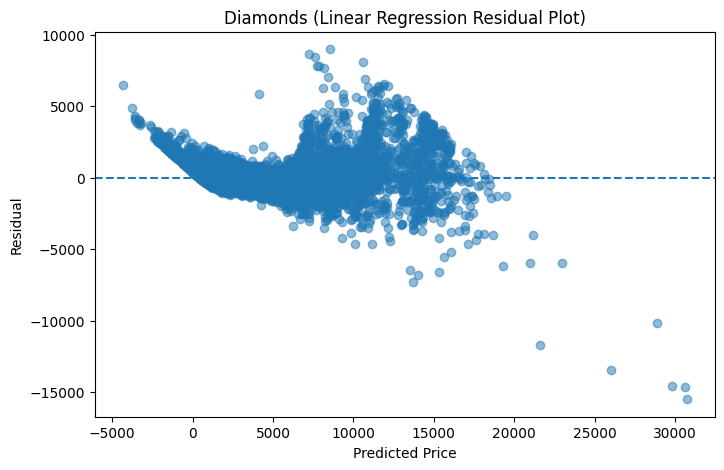

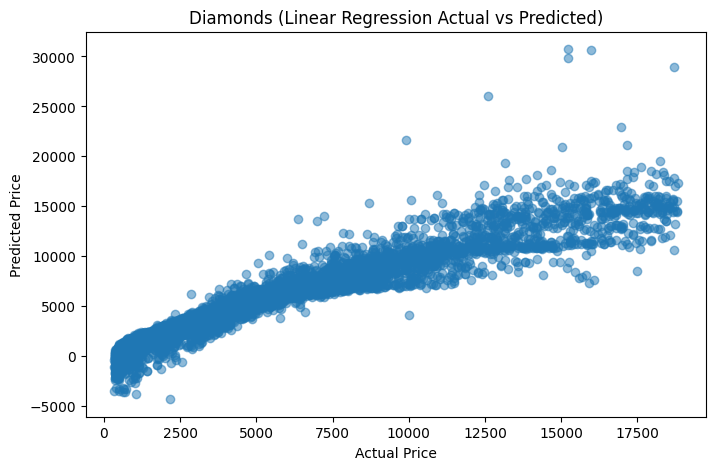

In [137]:
residuals_lin = yd_test - yd_pred_lin

plt.figure(figsize=(8, 5))
plt.scatter(yd_pred_lin, residuals_lin, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Diamonds (Linear Regression Residual Plot)")
plt.savefig("../figures/diamonds_linear_residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(yd_test, yd_pred_lin, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Diamonds (Linear Regression Actual vs Predicted)")
plt.savefig("../figures/diamonds_linear_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

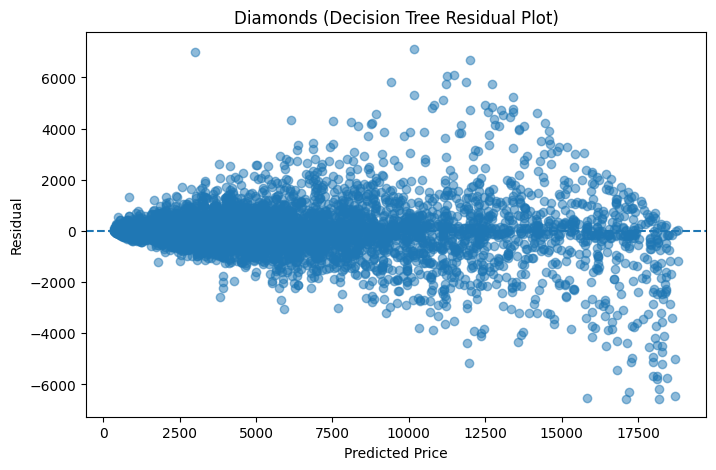

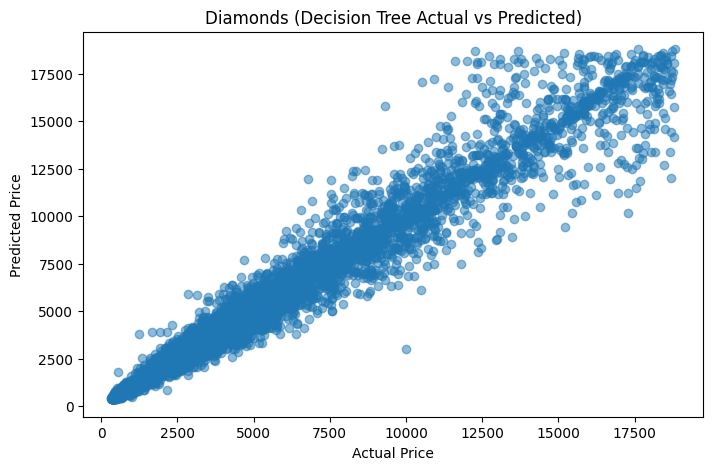

In [138]:
residuals_tree = yd_test - yd_pred_tree

plt.figure(figsize=(8, 5))
plt.scatter(yd_pred_tree, residuals_tree, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Diamonds (Decision Tree Residual Plot)")
plt.savefig("../figures/diamonds_tree_residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(yd_test, yd_pred_tree, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Diamonds (Decision Tree Actual vs Predicted)")
plt.savefig("../figures/diamonds_tree_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

The residual plots and actual-versus-predicted plots support the regression metrics. Linear Regression follows the overall trend, but its residual pattern shows that it cannot fully capture the structure of the data. Decision Tree Regressor tracks the actual prices much more closely, although some spread remains at higher price levels. These plots help explain why the nonlinear models achieved better regression scores.

## Hyperparameter tuning
For regression, I tuned KNN Regressor and Decision Tree Regressor. KNN is sensitive to the number of neighbors and weighting strategy, while Decision Tree Regressor is sensitive to tree depth and split requirements. These parameters affect how well the model balances flexibility and generalization.

In [139]:
knn_reg_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"]
}

knn_reg_search = GridSearchCV(
    knn_reg_pipe,
    knn_reg_grid,
    cv=3,
    scoring="r2"
)
knn_reg_search.fit(Xd_train, yd_train)

print("Best KNN Regressor params:", knn_reg_search.best_params_)
print("Best KNN Regressor CV R2:", knn_reg_search.best_score_)

Best KNN Regressor params: {'model__n_neighbors': 7, 'model__weights': 'distance'}
Best KNN Regressor CV R2: 0.9607078089910028


In [140]:
tree_reg_grid = {
    "model__max_depth": [5, 10, 15, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

tree_reg_search = GridSearchCV(
    tree_reg_pipe,
    tree_reg_grid,
    cv=3,
    scoring="r2"
)
tree_reg_search.fit(Xd_train, yd_train)

print("Best Tree Regressor params:", tree_reg_search.best_params_)
print("Best Tree Regressor CV R2:", tree_reg_search.best_score_)

Best Tree Regressor params: {'model__max_depth': 15, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}
Best Tree Regressor CV R2: 0.9716173345199316


In [141]:
best_knn_reg = knn_reg_search.best_estimator_
best_tree_reg = tree_reg_search.best_estimator_

yd_pred_knn_tuned = best_knn_reg.predict(Xd_test)
yd_pred_tree_tuned = best_tree_reg.predict(Xd_test)

diamond_tuned_results = pd.concat([
    evaluate_regression(yd_test, yd_pred_lin, "Linear Regression"),
    evaluate_regression(yd_test, yd_pred_knn_tuned, "Tuned KNN Regressor"),
    evaluate_regression(yd_test, yd_pred_tree_tuned, "Tuned Decision Tree Regressor"),
], ignore_index=True)

diamond_tuned_results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,737.151367,1.288705e+06,1135.211645,0.918933
1,Tuned KNN Regressor,369.422466,5.277552e+05,726.467616,0.966801
2,Tuned Decision Tree Regressor,332.370683,4.313595e+05,656.779651,0.972865


## Diamonds analysis
The diamonds dataset required the most preprocessing because it included both numerical and categorical predictors. That made it a good example of why pipelines and column-based preprocessing matter in practical machine learning work. Linear Regression gave a useful baseline, but the nonlinear models clearly performed better.
Among the baseline models, Decision Tree Regressor performed the best, with KNN Regressor close behind. Linear Regression had the largest errors and the lowest R2 score. The cross-validation results supported the same ranking, which suggests that the regression performance was stable and not caused by a lucky split.
After tuning, both nonlinear models improved. Tuned KNN Regressor improved over the baseline KNN model, while the tuned Decision Tree Regressor improved the most and remained the strongest overall model in this section. Its final R2 score was about 0.973, which was the best regression result in my notebook.

## Cross-Dataset Comparison
Using three different datasets made it easier to see that model performance depends heavily on the structure of the problem. The breast cancer dataset was the most straightforward because it had only two classes and mostly clean numerical predictors. In that section, Logistic Regression ended up performing best, which showed that a simpler model can sometimes be enough when the classes are already well separated.

The Dry Bean dataset was harder because it involved seven classes instead of two. That made the decision boundaries more complicated and created more opportunities for overlap between classes. In that section, MLPClassifier performed best, while Logistic Regression and KNN still remained competitive. This showed that as the structure of the problem becomes more complex, more flexible models can start to provide an advantage.

The diamonds dataset was different from the first two because it was a regression task and included both numerical and categorical features. That made preprocessing more important, since the data had to be handled through scaling, imputation, and one-hot encoding inside a pipeline. In that section, the nonlinear regression models performed better than Linear Regression, with the tuned Decision Tree Regressor giving the strongest final result.

Another clear pattern across my project was that tuning helped some models more than others. In the breast cancer section, tuning did not improve on the best baseline model. In the Dry Bean and Diamonds sections, tuning led to small but meaningful improvements for some of the more flexible models. Overall, the results support the idea that there is no single model that works best in every case. The right choice depends on the type of target variable, the structure of the features, and how complicated the relationship is between the inputs and outputs.

## Literature Comparison
To connect my results to prior work, I compared my breast cancer section to Abien Fred Agarap’s paper on the Wisconsin Diagnostic Breast Cancer dataset. In that study, six machine learning models were tested on the same dataset, and the data was split into 70% training and 30% testing. The paper reported strong results overall, with every model exceeding 90% test accuracy. Among the tested models, the multilayer perceptron produced the highest reported result at about 99.04% test accuracy.

My project used a smaller group of scikit-learn models, but the overall pattern was similar. The breast cancer dataset was one of the easiest sections in my notebook, and my best model also reached a very high performance level. That places my results in the same general range as the paper, even though the exact numbers were not identical.

There are several reasons for the difference. The paper used a different collection of models and manually assigned hyperparameters, while my notebook used a different workflow with train/test splitting, cross-validation, and grid-based tuning in selected models. Because of those differences, I would not expect the final scores to match exactly. Even so, both the published paper and my own results support the same conclusion that the Wisconsin breast cancer dataset is highly learnable, and standard supervised learning methods can perform very well on it.

In my notebook, Logistic Regression gave the strongest breast cancer result, while in the paper the best reported model was MLP, which shows that different workflows can favor different algorithms on the same dataset.

## Final Conclusion
This project followed the full supervised learning workflow across multiple datasets. I began by exploring each dataset, identifying the target variable, checking the structure of the data, and applying the preprocessing needed for that specific problem. After that, I trained baseline models, evaluated them with appropriate metrics and visualizations, tuned important hyperparameters, and compared the final results.

One of the biggest takeaways from the project is that no single model works best in every case. On the breast cancer dataset, the simpler linear model performed best because the classes were already separated well enough for Logistic Regression to handle effectively. On the Dry Bean dataset, the multiclass structure made the problem harder and gave an advantage to the more flexible MLPClassifier. On the diamonds dataset, the nonlinear regression models performed better than Linear Regression, especially after tuning.

Another important takeaway is that preprocessing matters just as much as model choice. Scaling helped the models that depended on feature magnitude, and the pipeline structure in the diamonds section was especially important because it kept the preprocessing tied directly to the regression models. The project also showed that hyperparameter tuning can help, but not always in the same way. Some tuned models improved noticeably, while others changed very little or still remained below the strongest baseline.

Overall, my project showed that model selection should be based on the dataset and the prediction task rather than on the assumption that one algorithm will always be best. The strongest results came from matching the preprocessing, model, and evaluation method to the structure of the data.

## Final model summary

In [142]:
print("Final Breast Cancer Results")
display(cancer_tuned_results)

print("Final Dry Bean Results")
display(bean_tuned_results)

print("Final Diamonds Results")
display(diamond_tuned_results)

Final Breast Cancer Results


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
1,Tuned KNN,0.938596,0.972973,0.857143,0.911392,0.982474
2,Tuned Decision Tree,0.938596,0.948718,0.880952,0.913580,0.922454


Final Dry Bean Results


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.920676,0.921533,0.920676,0.920873
1,Tuned KNN,0.918472,0.919200,0.918472,0.918580
2,Tuned MLPClassifier,0.929490,0.929565,0.929490,0.929345


Final Diamonds Results


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,737.151367,1.288705e+06,1135.211645,0.918933
1,Tuned KNN Regressor,369.422466,5.277552e+05,726.467616,0.966801
2,Tuned Decision Tree Regressor,332.370683,4.313595e+05,656.779651,0.972865


# References
1. UCI Machine Learning Repository. *Breast Cancer Wisconsin (Diagnostic) Data Set*.
2. UCI Machine Learning Repository. *Dry Bean Dataset*.
3. Agarap, Abien Fred. *On Breast Cancer Detection: An Application of Machine Learning Algorithms on the Wisconsin Diagnostic Dataset*.
4. Kaggle. Shivam Agrawal. *Diamonds* dataset.